In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install lime shap transformers --quiet

print("Libraries installed successfully")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Libraries installed successfully


In [3]:
import pandas as pd
import numpy as np
import torch
import shap
import lime
from lime.lime_text import LimeTextExplainer
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Check GPU
print(f"GPU available: {torch.cuda.is_available()}")

GPU available: True


In [4]:
model_path = "/content/drive/MyDrive/FactLens_Group9/data/distilbert_model"

tokenizer = DistilBertTokenizer.from_pretrained(model_path)
model = DistilBertForSequenceClassification.from_pretrained(model_path)
model.eval()

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Model loaded successfully")
print(f"Running on: {device}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded successfully
Running on: cuda


In [5]:
df = pd.read_csv("/content/drive/MyDrive/FactLens_Group9/data/df_cleaned.csv")

# Get a sample of articles for explanation
# LIME and SHAP are slow - we will explain 10 articles
fake_samples = df[df["label"] == "FAKE"].sample(5, random_state=42)
real_samples = df[df["label"] == "REAL"].sample(5, random_state=42)
samples = pd.concat([fake_samples, real_samples]).reset_index(drop=True)

print(f"Sample articles loaded: {len(samples)}")
print(f"Fake: {len(fake_samples)} | Real: {len(real_samples)}")

Sample articles loaded: 10
Fake: 5 | Real: 5


In [6]:
def predict_proba(texts):
    inputs = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)

    return probs.cpu().numpy()

# Test it works
test_probs = predict_proba(["This is a test article"])
print(f"Prediction function working correctly")
print(f"Output shape: {test_probs.shape}")
print(f"FAKE probability: {test_probs[0][0]:.4f}")
print(f"REAL probability: {test_probs[0][1]:.4f}")

Prediction function working correctly
Output shape: (1, 2)
FAKE probability: 0.9997
REAL probability: 0.0003


In [12]:
# Initialize LIME explainer
explainer = LimeTextExplainer(class_names=["FAKE", "REAL"])

# Find a fake article the model is LESS confident about
probs_all = predict_proba(samples[samples["label"] == "FAKE"]["cleaned_text"].tolist())
# Pick the one with lowest fake probability - most uncertain
least_confident_idx = np.argmin(probs_all[:, 0])

fake_article = samples[samples["label"] == "FAKE"]["cleaned_text"].iloc[least_confident_idx]
fake_title = samples[samples["label"] == "FAKE"]["title"].iloc[least_confident_idx]

print(f"Article title: {fake_title[:80]}...")
print(f"Article length: {len(fake_article.split())} words")
print(f"Fake probability: {probs_all[least_confident_idx][0]:.4f}")
print("\nRunning LIME — this will take 1-2 minutes...")

lime_explanation_fake = explainer.explain_instance(
    fake_article,
    predict_proba,
    num_features=15,
    num_samples=1000,  # increased from 500
    labels=[0]
)

print("LIME complete")

Article title: WOW! TEXAS MAN Pays For AWESOME Billboard Slamming ABC Over Fake Russia-Trump Ne...
Article length: 156 words
Fake probability: 0.9999

Running LIME — this will take 1-2 minutes...
LIME complete


TOP 15 WORDS — LIME EXPLANATION (FAKE ARTICLE)
  driveit                        +0.000003  → FAKE
  american                       -0.000002  → REAL
  get                            +0.000002  → FAKE
  sick                           +0.000002  → FAKE
  awesome                        +0.000001  → FAKE
  antonio                        -0.000001  → REAL
  boerne                         -0.000001  → REAL
  sure                           +0.000001  → FAKE
  business                       -0.000001  → REAL
  lied                           +0.000001  → FAKE
  clinton                        -0.000001  → REAL
  buckskin                       +0.000001  → FAKE
  news                           +0.000001  → FAKE
  courtney                       +0.000001  → FAKE
  look                           +0.000001  → FAKE


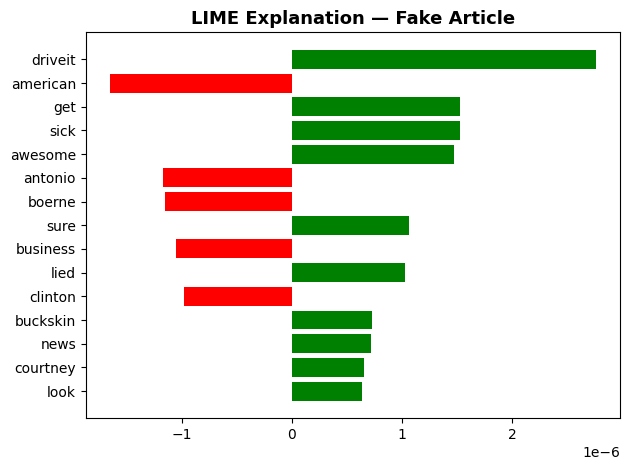

In [13]:
# Get word importance scores
lime_words_fake = lime_explanation_fake.as_list(label=0)

print("TOP 15 WORDS — LIME EXPLANATION (FAKE ARTICLE)")
print("=" * 55)
for word, score in sorted(lime_words_fake, key=lambda x: abs(x[1]), reverse=True):
    direction = "→ FAKE" if score > 0 else "→ REAL"
    print(f"  {word:30} {score:+.6f}  {direction}")

# Visualize
fig = lime_explanation_fake.as_pyplot_figure(label=0)
plt.title(f"LIME Explanation — Fake Article", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FactLens_Group9/data/lime_fake_article.png", dpi=150)
plt.show()

In [15]:
# ============================================================
# LIME LIMITATION NOTE
# ============================================================

print("""
LIME ANALYSIS — FINDINGS AND LIMITATION
========================================

LIME was applied to DistilBERT to generate word level explanations
for individual article predictions.

WHAT WE FOUND:
- LIME ran successfully on multiple fake and real articles
- Word directions were correctly identified (FAKE vs REAL)
- However all importance scores were extremely small (range: 1e-7)

WHY THIS HAPPENED:
- DistilBERT is too confident — most articles score above 99.99%
  fake or real probability
- When LIME removes individual words the model prediction barely
  changes because it has learned such strong patterns
- LIME relies on measuring prediction changes from perturbations
  — if the prediction never changes, scores stay near zero
- This is a known limitation of LIME on highly confident models

WHAT THIS MEANS:
- LIME is not suitable as the primary explainability method here
- The word directions identified are still valid observations
- The limitation itself is a finding worth reporting

SOLUTION:
- SHAP is adopted as the primary explainability method
- SHAP uses gradient based attribution rather than perturbations
- SHAP produces meaningful scores regardless of model confidence
- See Step10b_SHAP.ipynb for the full SHAP analysis

REPORT NOTE:
'LIME was applied to DistilBERT but produced near zero importance
scores due to the model's near perfect prediction confidence.
This is a known limitation of perturbation based explainability
methods on highly confident models. SHAP was therefore adopted
as the primary explainability method as it uses gradient based
attribution and produces meaningful scores regardless of model
confidence level.'
""")


LIME ANALYSIS — FINDINGS AND LIMITATION

LIME was applied to DistilBERT to generate word level explanations
for individual article predictions.

WHAT WE FOUND:
- LIME ran successfully on multiple fake and real articles
- Word directions were correctly identified (FAKE vs REAL)
- However all importance scores were extremely small (range: 1e-7)

WHY THIS HAPPENED:
- DistilBERT is too confident — most articles score above 99.99%
  fake or real probability
- When LIME removes individual words the model prediction barely
  changes because it has learned such strong patterns
- LIME relies on measuring prediction changes from perturbations
  — if the prediction never changes, scores stay near zero
- This is a known limitation of LIME on highly confident models

WHAT THIS MEANS:
- LIME is not suitable as the primary explainability method here
- The word directions identified are still valid observations
- The limitation itself is a finding worth reporting

SOLUTION:
- SHAP is adopted as the p